In [74]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib import rc_context
import matplotlib.pyplot as plt
import os

In [75]:
figure_dir = r'..\figures\serumCorrelation'

# serum data

In [46]:
serum_level = {'anti-Ro52': [3,1,4,1,2,145,96,78,72],
               'anti-Ro60': [5,0,1,0,0,110,115,0,122]}
serum_level = pd.DataFrame(serum_level)
serum_level.index = ['7202','128','126','7223','103','83','84','127','141']

In [29]:
serum_level.to_csv(r'Y:\coskun-lab\Zhou\12_MSG\ARUP Results 10-2-2025.csv')

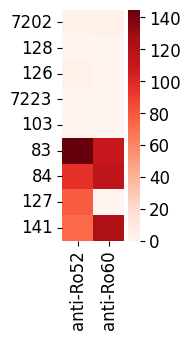

In [32]:
with rc_context({'figure.figsize':(1,3), 'font.size':12}):
    sns.heatmap(serum_level, cmap='Reds')
    plt.savefig(os.path.join(figure_dir, 'serum_levels_heatmap.png'), dpi=300, bbox_inches='tight')

In [36]:
selected = serum_level.loc[['126','7223','103','83','141']]
selected.rename(index={'126':'Donor 7', '7223':'Donor 12', '103':'Donor 5', '83':'Donor 1', '141':'Donor 10'}, inplace=True)

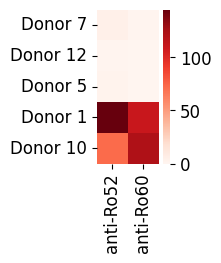

In [38]:
with rc_context({'figure.figsize':(1,2), 'font.size':12}):
    sns.heatmap(selected, cmap='Reds')
    plt.savefig(os.path.join(figure_dir, 'serum_levels_heatmap_selected.png'), dpi=300, bbox_inches='tight')

# tissue data

In [80]:
# 7202
adata = sc.read_h5ad(r'Y:\coskun-lab2\Zhou\12_MSG\ssa_if_analysis\results\singleCell\IF.h5ad')

In [81]:
observation = adata.obs.copy()

In [82]:
observation['Sample'].unique()

['83', '134', '141', '103', '72231', '72232', '1261', '1262']
Categories (8, object): ['83', '103', '134', '141', '1261', '1262', '72231', '72232']

In [62]:
ro52_83 = observation[observation['Sample']=='83']['RO52'].tolist()
ro60_83 = observation[observation['Sample']=='83']['RO60'].tolist()
ro52_134 = observation[observation['Sample']=='134']['RO52'].tolist()
ro60_134 = observation[observation['Sample']=='134']['RO60'].tolist()
ro52_141 = observation[observation['Sample']=='141']['RO52'].tolist()
ro60_141 = observation[observation['Sample']=='141']['RO60'].tolist()
ro52_103 = observation[observation['Sample']=='103']['RO52'].tolist()
ro60_103 = observation[observation['Sample']=='103']['RO60'].tolist()
ro52_72231 = observation[observation['Sample']=='72231']['RO52'].tolist()
ro60_72231 = observation[observation['Sample']=='72231']['RO60'].tolist()
ro52_72232 = observation[observation['Sample']=='72232']['RO52'].tolist()
ro60_72232 = observation[observation['Sample']=='72232']['RO60'].tolist()
ro52_7223 = ro52_72231 + ro52_72232
ro60_7223 = ro60_72231 + ro60_72232
ro52_1261 = observation[observation['Sample']=='1261']['RO52'].tolist()
ro60_1261 = observation[observation['Sample']=='1261']['RO60'].tolist()
ro52_1262 = observation[observation['Sample']=='1262']['RO52'].tolist()
ro60_1262 = observation[observation['Sample']=='1262']['RO60'].tolist()
ro52_126 = ro52_1261 + ro52_1262
ro60_126 = ro60_1261 + ro60_1262

In [63]:
# selected = serum_level.loc[['126','7223','103','83','141']]

In [64]:
selected['Ro52 IF'] = [np.mean(ro52_126), np.mean(ro52_7223), np.mean(ro52_103), np.mean(ro52_83), np.mean(ro52_141)]
selected['Ro60 IF'] = [np.mean(ro60_126), np.mean(ro60_7223), np.mean(ro60_103), np.mean(ro60_83), np.mean(ro60_141)]

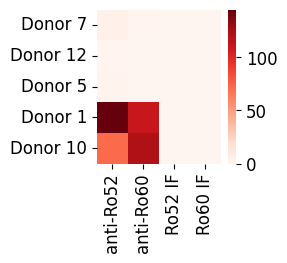

In [53]:
with rc_context({'figure.figsize':(2,2), 'font.size':12}):
    sns.heatmap(selected, cmap='Reds')
    plt.savefig(os.path.join(figure_dir, 'serum_if_levels_heatmap_selected.png'), dpi=300, bbox_inches='tight')

In [65]:
if_df = pd.DataFrame({'Ro52 IF': selected['Ro52 IF'].tolist(),
                      'Ro60 IF': selected['Ro60 IF'].tolist()})
if_df.index = selected.index

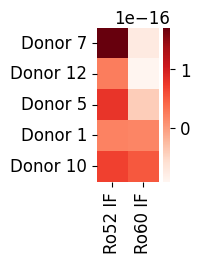

In [66]:
with rc_context({'figure.figsize':(1,2), 'font.size':12}):
    sns.heatmap(if_df, cmap='Reds')
    plt.savefig(os.path.join(figure_dir, 'if_levels_heatmap_selected.png'), dpi=300, bbox_inches='tight')

In [68]:
ro52_83 = observation[observation['Sample']=='83']['Ro52_raw'].tolist()
ro60_83 = observation[observation['Sample']=='83']['Ro60_raw'].tolist()
ro52_134 = observation[observation['Sample']=='134']['Ro52_raw'].tolist()
ro60_134 = observation[observation['Sample']=='134']['Ro60_raw'].tolist()
ro52_141 = observation[observation['Sample']=='141']['Ro52_raw'].tolist()
ro60_141 = observation[observation['Sample']=='141']['Ro60_raw'].tolist()
ro52_103 = observation[observation['Sample']=='103']['Ro52_raw'].tolist()
ro60_103 = observation[observation['Sample']=='103']['Ro60_raw'].tolist()
ro52_72231 = observation[observation['Sample']=='72231']['Ro52_raw'].tolist()
ro60_72231 = observation[observation['Sample']=='72231']['Ro60_raw'].tolist()
ro52_72232 = observation[observation['Sample']=='72232']['Ro52_raw'].tolist()
ro60_72232 = observation[observation['Sample']=='72232']['Ro60_raw'].tolist()
ro52_7223 = ro52_72231 + ro52_72232
ro60_7223 = ro60_72231 + ro60_72232
ro52_1261 = observation[observation['Sample']=='1261']['Ro52_raw'].tolist()
ro60_1261 = observation[observation['Sample']=='1261']['Ro60_raw'].tolist()
ro52_1262 = observation[observation['Sample']=='1262']['Ro52_raw'].tolist()
ro60_1262 = observation[observation['Sample']=='1262']['Ro60_raw'].tolist()
ro52_126 = ro52_1261 + ro52_1262
ro60_126 = ro60_1261 + ro60_1262

In [ ]:
selected['Ro52 IF'] = [np.mean(ro52_126), np.mean(ro52_7223), np.mean(ro52_103), np.mean(ro52_83), np.mean(ro52_141)]
selected['Ro60 IF'] = [np.mean(ro60_126), np.mean(ro60_7223), np.mean(ro60_103), np.mean(ro60_83), np.mean(ro60_141)]

In [70]:
if_df = pd.DataFrame({'Ro52 IF': selected['Ro52 IF'].tolist(),
                      'Ro60 IF': selected['Ro60 IF'].tolist()})
if_df.index = selected.index

In [72]:
# log of entire dataframe
if_df = np.log(if_df)

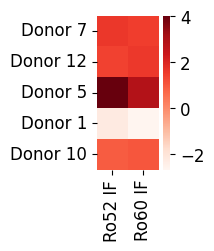

In [73]:
with rc_context({'figure.figsize':(1,2), 'font.size':12}):
    sns.heatmap(if_df, cmap='Reds')
    plt.savefig(os.path.join(figure_dir, 'if_levels_heatmap_selected_raw.png'), dpi=300, bbox_inches='tight')

In [83]:
ro52_83 = observation[observation['Sample']=='83']['Ro52_scanorama'].tolist()
ro60_83 = observation[observation['Sample']=='83']['Ro60_scanorama'].tolist()
ro52_134 = observation[observation['Sample']=='134']['Ro52_scanorama'].tolist()
ro60_134 = observation[observation['Sample']=='134']['Ro60_scanorama'].tolist()
ro52_141 = observation[observation['Sample']=='141']['Ro52_scanorama'].tolist()
ro60_141 = observation[observation['Sample']=='141']['Ro60_scanorama'].tolist()
ro52_103 = observation[observation['Sample']=='103']['Ro52_scanorama'].tolist()
ro60_103 = observation[observation['Sample']=='103']['Ro60_scanorama'].tolist()
ro52_72231 = observation[observation['Sample']=='72231']['Ro52_scanorama'].tolist()
ro60_72231 = observation[observation['Sample']=='72231']['Ro60_scanorama'].tolist()
ro52_72232 = observation[observation['Sample']=='72232']['Ro52_scanorama'].tolist()
ro60_72232 = observation[observation['Sample']=='72232']['Ro60_scanorama'].tolist()
ro52_7223 = ro52_72231 + ro52_72232
ro60_7223 = ro60_72231 + ro60_72232
ro52_1261 = observation[observation['Sample']=='1261']['Ro52_scanorama'].tolist()
ro60_1261 = observation[observation['Sample']=='1261']['Ro60_scanorama'].tolist()
ro52_1262 = observation[observation['Sample']=='1262']['Ro52_scanorama'].tolist()
ro60_1262 = observation[observation['Sample']=='1262']['Ro60_scanorama'].tolist()
ro52_126 = ro52_1261 + ro52_1262
ro60_126 = ro60_1261 + ro60_1262

In [84]:
selected['Ro52 IF'] = [np.mean(ro52_126), np.mean(ro52_7223), np.mean(ro52_103), np.mean(ro52_83), np.mean(ro52_141)]
selected['Ro60 IF'] = [np.mean(ro60_126), np.mean(ro60_7223), np.mean(ro60_103), np.mean(ro60_83), np.mean(ro60_141)]

In [88]:
if_df = pd.DataFrame({'Ro52 IF': selected['Ro52 IF'].tolist(),
                      'Ro60 IF': selected['Ro60 IF'].tolist()})
if_df.index = selected.index

In [89]:
# log of entire dataframe
# if_df = np.log(if_df)

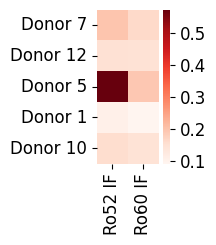

In [90]:
with rc_context({'figure.figsize':(1,2), 'font.size':12}):
    sns.heatmap(if_df, cmap='Reds')
    plt.savefig(os.path.join(figure_dir, 'if_levels_heatmap_selected_scanorama.png'), dpi=300, bbox_inches='tight')

# scanorama normalization